# Softmax Regression — từ công thức toán đến code trên văn bản tiếng Việt (ViHSD)

Notebook này áp dụng **softmax regression** cho bài toán phân loại văn bản tiếng Việt **3 lớp** từ bộ dữ liệu **ViHSD** (Vietnamese Hate and Speech Detection):

| `label_id` | Ý nghĩa |
|---|---|
| `0` | CLEAN — bình luận bình thường |
| `1` | OFFENSIVE — phản cảm, thô tục |
| `2` | HATE — thù ghét, kích động |

Đây là bài toán **phân loại đa lớp** ($K=3$) trên **văn bản**. Khác Iris (đặc trưng là 4 số đo hoa), đặc trưng ở đây là **vector TF-IDF** đếm từ — nhưng **phần toán softmax thì hoàn toàn giống Iris**; chỉ cách tạo đặc trưng là khác (xem Mục 2).

Môn `ml_ad` yêu cầu mỗi thuật toán đi đủ **các giai đoạn** theo thứ tự:
1. **GIẢI TAY** — dẫn xuất gradient từng bước, thay số cụ thể, kiểm chứng bằng sai phân hữu hạn.
2. **BẢN THUẦN** — NumPy duy nhất, từ công thức, không thư viện ML.
3. **BẢN THƯ VIỆN** — `scikit-learn` (`LogisticRegression`).
4. **SO SÁNH & KẾT LUẬN** — bảng + biểu đồ, lý giải khoảng cách thuần–thư viện.

> Báo cáo lý thuyết chi tiết xem `report_softmax_regression.md` (cùng phương pháp 4 giai đoạn).

## 0. Nạp dữ liệu ViHSD và xem phân bố lớp

Duong dan du lieu: ../../b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/ViHSD.csv
Tong so mau: 33398 | so cot: ['free_text', 'label_id', 'split']
Phan bo lop (goc, lech):
   0 CLEAN     : 27623
   1 OFFENSIVE : 2261
   2 HATE      : 3514


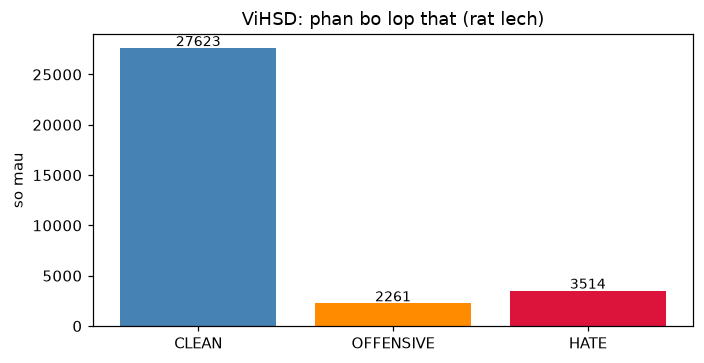

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

# Duong dan du lieu: chon ung cuong nao ton tai (de notebook chay duoc tu nhieu thu muc)
_cands = [
    "../../b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/ViHSD.csv",
    "../b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/ViHSD.csv",
    "/home/alexdev/Projects/learning-master-ute/ml_ad/b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/ViHSD.csv",
]
CSV = next((p for p in _cands if os.path.exists(p)), _cands[0])
print("Duong dan du lieu:", CSV)

cls = {0: "CLEAN", 1: "OFFENSIVE", 2: "HATE"}
df = pd.read_csv(CSV)
print("Tong so mau:", len(df), "| so cot:", list(df.columns))
vc = df["label_id"].value_counts().sort_index()
print("Phan bo lop (goc, lech):")
for k, v in vc.items():
    print("  %2d %-9s : %d" % (k, cls[k], v))

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar([cls[i] for i in vc.index], vc.values,
       color=["steelblue", "darkorange", "crimson"])
ax.set_ylabel("so mau"); ax.set_title("ViHSD: phan bo lop that (rat lech)")
for i, v in enumerate(vc.values):
    ax.text(i, v + 200, str(v), ha="center", fontsize=9)
fig.tight_layout(); plt.show()

**Nhận xét.** Dữ liệu **rất lệch**: CLEAN áp đảo (~27 600 mẫu) trong khi OFFENSIVE (~2 260) và HATE (~3 510) ít hơn nhiều. Với dữ liệu lệch thế này, **độ chính xác (accuracy) dễ đánh lừa** — đoán toàn bộ là CLEAN đã đạt ~80%. Thước đo đúng là **F1-macro** (trung bình F1 của từng lớp), giống phân tích EDA ở `b1`/`b3`.

Để bản thuần chạy vừa kịp thời gian trên máy và cân bằng 3 lớp, ta **lấy tối đa 2 000 mẫu mỗi lớp** (lấy ngẫu nhiên, cố định `seed`). Trước khi vector hoá, chia 80/20 có phân tầng (`stratify`) để giữ tỷ lệ lớp.

In [2]:
# Lay toi da 2000 mau/lop -> can bang (pandas 3.0: lap tung nhom thay vi apply)
parts = [g.sample(min(len(g), 2000), random_state=1) for _, g in df.groupby("label_id")]
sub = pd.concat(parts)
X_text = sub["free_text"].fillna("").astype(str).values
y = sub["label_id"].values
print("Sau khi can bang:", dict(zip([cls[i] for i in range(3)], np.bincount(y))))

Xtr_t, Xte_t, ytr, yte = train_test_split(X_text, y, test_size=0.2,
                                          random_state=1, stratify=y)
print("Kich thuoc train/test (van ban):", Xtr_t.shape, Xte_t.shape)
print("\nVi du 1 mau OFFENSIVE:", repr(Xtr_t[ytr == 1][0][:80]), "...")

Sau khi can bang: {'CLEAN': np.int64(2000), 'OFFENSIVE': np.int64(2000), 'HATE': np.int64(2000)}
Kich thuoc train/test (van ban): (4800,) (1200,)

Vi du 1 mau OFFENSIVE: 'Thang cc nao ma chang the dc,' ...


## 1. Biến văn bản thành số — TF-IDF (đây là điểm KHÁC Iris)

Mô hình softmax chỉ nhận **vector số** $x$. Văn bản phải được vector hoá. Ta dùng **TF-IDF**: mỗi chiều là một từ (hoặc cụm 2 từ), giá trị cao khi từ đó xuất hiện nhiều trong bình luận này nhưng hiếm trong cả tập.

- **TF** (term frequency): tần suất từ trong bình luận.
- **IDF** (inverse document frequency): từ hiếm trên toàn tập sẽ có trọng số lớn → mang nhiều thông tin phân biệt.
- TF-IDF = TF × IDF. Càng cao → từ càng "đặc trưng" cho bình luận này.

Tham số: `max_features=3000` (giữ 3 000 từ/cụm từ quan trọng nhất), `ngram_range=(1,2)` (cả từ đơn và cụm 2 từ — bắt được "đúng là", "mắt hí"...), `min_df=2` (bỏ từ chỉ xuất hiện 1 lần).

**Quan trọng:** vector đặc trưng $x$ giờ là TF-IDF (3 000 chiều), nhưng mọi công thức softmax ở Mục 2–3 **giống hệt Iris**.

In [3]:
vec = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
Xtr = vec.fit_transform(Xtr_t).toarray()    # dense de pure-numpy nhan ma tran
Xte = vec.transform(Xte_t).toarray()
d = Xtr.shape[1]
print("Xtr:", Xtr.shape, "| Xte:", Xte.shape, "| so dac trung (d) =", d)

# Xem vai gia tri TF-IDF khac 0 cua mau dau tien
nz = np.flatnonzero(Xtr[0])[:5]
vocab = np.array(vec.get_feature_names_out())
print("\n5 dac trung dau (khac 0) cua mau train[0]:")
for j in nz:
    print("  %-16s tfidf=%.4f" % (vocab[j], Xtr[0, j]))
print("Ti le phan tu khac 0: %.4f" % (np.mean(Xtr != 0)))

Xtr: (4800, 3000) | Xte: (1200, 3000) | so dac trung (d) = 3000

5 dac trung dau (khac 0) cua mau train[0]:
  cai              tfidf=0.3135
  chi              tfidf=0.2649
  cong             tfidf=0.3971
  len              tfidf=0.4043
  ma               tfidf=0.2637
Ti le phan tu khac 0: 0.0043


## 2. Vì sao cần softmax và mô hình

Bài toán có 3 lớp. Với 2 lớp, hồi quy logistic dùng sigmoid $\sigma(z)\in(0,1)$. Với $K$ lớp, cần **một phân phối xác suất** trên $K$ đầu ra (mỗi giá trị dương, tổng đúng 1). Hàm **softmax** đáp ứng đúng yêu cầu đó — nó là tổng quát hoá tự nhiên của sigmoid.

Với một mẫu có vector đặc trưng $x$ (TF-IDF, $d$ chiều), điểm số thô (logit) của $K$ lớp là:
$$z = W^{\top} x + b,\quad W \in \mathbb{R}^{d\times K},\ b \in \mathbb{R}^{K}.$$
Xác suất mỗi lớp qua **softmax**:
$$\hat{y}_k = p_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}.$$
Với nhãn thật one-hot $y$, mất mát entropy chéo của 1 mẫu là $\ell = -\sum_k y_k \log p_k$; trên cả tập $N$ mẫu, ta cực tiểu hoá $\mathcal{L} = -\tfrac{1}{N}\sum_i \log \hat{y}_{i,c_i}$.

## 3. GIẢI TAY — dẫn xuất gradient từng bước

Mục tiêu: tìm $\partial\ell/\partial z$ để biết phải sửa $z$ (và qua đó là $W, b$) theo hướng nào. Với $\ell = -\sum_k y_k \log p_k$ và $p_k = e^{z_k}/\sum_j e^{z_j}$, đạo hàm cho ra kết quả rất đẹp:
$$\frac{\partial\ell}{\partial z_k} = p_k - y_k,\quad\text{tức}\quad \frac{\partial\ell}{\partial z} = p - y.$$
Theo $W$ và $b$ (vì $z = W^{\top} x + b$):
$$\frac{\partial\mathcal{L}}{\partial W} = \frac{1}{N}X^{\top}(P-Y),\qquad \frac{\partial\mathcal{L}}{\partial b} = \frac{1}{N}\sum_i (p_i - y_i).$$

**Tính đẹp của softmax + entropy chéo:** gradient của logit chỉ là $(P - Y)$ — sai số dự đoán trừ nhãn. Nhờ vậy bản thuần chỉ cần hai phép ma trận, không cần đạo hàm bậc hai hay autograd. Bước kế kiểm chứng công thức này bằng **sai phân hữu hạn**.

### 3bis. Giải tay với số cụ thể (thay số vào công thức)

Để thấy công thức "chạy" thế nào, ta thay số từng bước cho một bình luận phản cảm ngắn, giả sử chỉ có 4 đặc trưng (từ) để tính tay được.

**Bảng ý nghĩa từng kí hiệu** — đọc trước khi xem tính toán (toán softmax giống hệt Iris; chỉ `x` giờ là vector TF-IDF thay vì số đo hoa):

| Kí hiệu | Đọc là | Ý nghĩa | Kích thước | Giá trị ở mẫu này |
|---|---|---|---|---|
| `x` | "x" | vector đặc trưng TF-IDF của 1 bình luận | (3000,) thật; (4,) ví dụ | [0.52, 0.31, 0.00, 0.18] |
| `W` | "W" | ma trận trọng số — mỗi **cột** là trọng số của 1 lớp | (d, 3) | (cho ở dưới) |
| `b` | "b" | thiên lệch (bias) của 3 lớp | (3,) | [0.10, 0.00, 0.20] |
| `z = W·x + b` | "z" | **điểm số thô** (logit) của 3 lớp; càng cao càng giống | (3,) | [0.2595, 0.221, 0.32] |
| `p = softmax(z)` | "p" | **xác suất** 3 lớp (dương, tổng = 1) | (3,) | [0.3306, 0.3181, 0.3512] |
| `y` | "y" | nhãn thật dạng **one-hot** (lớp đúng = 1) | (3,) | [0, 1, 0] (OFFENSIVE) |
| `ℓ` | "ell" | **mất mát** entropy chéo (càng nhỏ càng tốt) | số | 1.1453 |
| `∂ℓ/∂z = p − y` | "grad-z" | đạo hàm mất mát theo điểm số — *hướng* cần sửa | (3,) | [0.3306, −0.6819, 0.3512] |

**Đầu vào cụ thể.** Một bình luận OFFENSIVE, vector TF-IDF (4 từ đặc trưng): `x = [0.52, 0.31, 0.00, 0.18]` (từ thứ 3 không xuất hiện nên TF-IDF = 0). Bộ trọng số minh hoạ:
`W = [[0.20, 0.10, 0.05], [0.15, 0.40, 0.10], [0.30, 0.20, 0.50], [0.05, 0.25, 0.35]]` (4×3),  `b = [0.10, 0.00, 0.20]`.

**Bước 1 — Điểm số `z = W·x + b`** (mỗi lớp = tích vô hướng giữa `x` và một cột của `W`, cộng thiên lệch):
- `z₀ = 0.20·0.52 + 0.15·0.31 + 0.30·0.00 + 0.05·0.18 + 0.10 = 0.1040+0.0465+0.0090+0.1000 = 0.2595`  → CLEAN
- `z₁ = 0.10·0.52 + 0.40·0.31 + 0.20·0.00 + 0.25·0.18 + 0.00 = 0.0520+0.1240+0.0450 = 0.221`  → OFFENSIVE
- `z₂ = 0.05·0.52 + 0.10·0.31 + 0.50·0.00 + 0.35·0.18 + 0.20 = 0.0260+0.0310+0.0630+0.2000 = 0.32`  → HATE

**Bước 2 — Softmax** (trừ max trước khi lấy exp để chống tràn số). `max(z) = 0.32`, nên `z′ = z − 0.32 = [−0.0605, −0.0990, 0]`:
- `exp(z′) = [0.9413, 0.9057, 1.0000]`,  tổng = `2.8470`
- `p = exp(z′) / 2.8470 = [0.3306, 0.3181, 0.3512]`  → mô hình đoán HATE (0.3512 cao nhất) → **sai** (nhãn thật là OFFENSIVE). Đây đúng là nhầm lẫn khó nhất của bài toán: OFFENSIVE và HATE rất dễ lẫn nhau.

**Bước 3 — Mất mát entropy chéo.** Nhãn thật lớp 1 ⇒ `y = [0, 1, 0]`. Entropy chéo **chỉ phạt lớp đúng**:
`ℓ = −log(p₁) = −log(0.3181) = 1.1453`
Loss khá lớn vì mô hình gán xác suất thấp (0.3181) cho lớp đúng.

**Bước 4 — Gradient** `∂ℓ/∂z = p − y` (công thức đã dẫn ở Mục 3):
`∂ℓ/∂z = [0.3306−0, 0.3181−1, 0.3512−0] = [0.3306, −0.6819, 0.3512]`
- **Âm** ở lớp 1 (−0.6819): gradient âm ⇒ gradient descent **tăng** `z₁` lên → `p₁` lớn hơn (đúng hướng, vì OFFENSIVE mới là nhãn thật).
- **Dương** ở lớp 0 và 2: gradient descent **giảm** `z₀, z₂` → bớt đoán nhầm sang CLEAN/HATE.

Cell kế tiếp chạy đúng các con số trên bằng mã, **vẽ thành sơ đồ**, và đối chiếu gradient giải tích với sai phân hữu hạn.

In [4]:
# === Giai doan 1: GIAI TAY tren 1 mau (vi du nho) ===
x0 = np.array([0.52, 0.31, 0.00, 0.18])            # vector TF-IDF cua 1 binh luan
W0 = np.array([[.20, .10, .05],
               [.15, .40, .10],
               [.30, .20, .50],
               [.05, .25, .35]])                  # (4, 3)
b0 = np.array([0.10, 0.00, 0.20])
z0 = W0.T @ x0 + b0
print("z   =", z0)
p0 = np.exp(z0 - z0.max()); p0 /= p0.sum()        # softmax ON DINH (tru max)
print("p   =", p0, " (tong = %.4f)" % p0.sum())
y0 = np.array([0, 1, 0], dtype=float)             # OFFENSIVE -> lop 1
loss0 = -np.sum(y0 * np.log(p0))
print("loss (entropy cheo) = %.4f" % loss0)
grad_z0 = p0 - y0
print("dL/dz = p - y =", grad_z0)
print("dL/dW = x (p-y)^T ->\n", np.round(np.outer(x0, grad_z0), 4))

# === Ham softmax / loss_and_grad dung cho batch (matrix) ===
K = 3
def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)          # tru max: chong tran (overflow)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

def loss_and_grad(W, b, X, Y):
    P = softmax(X @ W + b); n = len(X)
    L = -np.mean(np.sum(Y * np.log(P + 1e-12), axis=1))
    gW = X.T @ (P - Y) / n
    gb = (P - Y).mean(axis=0)
    return L, gW, gb

# === Kiem chung gradient bang sai phan huu han ===
eps = 1e-6
def fd_grad(W, b, X, Y, i, j):
    Wp = W.copy(); Wp[i, j] += eps
    Lp, _, _ = loss_and_grad(Wp, b, X, Y)
    Wm = W.copy(); Wm[i, j] -= eps
    Lm, _, _ = loss_and_grad(Wm, b, X, Y)
    return (Lp - Lm) / (2 * eps)

# a) Tren vi du nho (4 dac trung): kiem het 4x3 = 12 trong so
X0m, Y0m = x0.reshape(1, -1), y0.reshape(1, -1)
_, gW0, _ = loss_and_grad(W0, b0, X0m, Y0m)
gW0_num = np.array([[fd_grad(W0, b0, X0m, Y0m, i, j) for j in range(K)] for i in range(4)])
diff0 = np.abs(gW0 - gW0_num).max()
print("\nKiem chung (vi du nho, 12 trong so): max|giai tich - sai phan| = %.2e" % diff0)

# b) Tren du lieu that TF-IDF: lay 1 batch nho (80 mau), kiem ngau nhien 8 trong so
#    (3000 dac trung nen khong kiem het nhu Iris 4 dac trung)
rng = np.random.default_rng(0)
idx = rng.choice(len(Xtr), size=80, replace=False)
Xb, yb = Xtr[idx], ytr[idx]
Yb = np.eye(K)[yb]
Wi = rng.normal(size=(Xtr.shape[1], K)) * 0.01
bi = np.zeros(K)
_, gW_real, _ = loss_and_grad(Wi, bi, Xb, Yb)
chk = rng.integers(0, Xtr.shape[1], size=8)
diff_real = max(abs(gW_real[r, c] - fd_grad(Wi, bi, Xb, Yb, r, c))
                for r in chk for c in range(K))
print("Kiem chung (batch that %d mau, %d trong so): max|...| = %.2e"
      % (len(Xb), len(chk) * K, diff_real))
print("=> CONG THUC O MUC 3 DUNG" if max(diff0, diff_real) < 1e-5
      else "=> CONG THUC SAI, can xem lai")

z   = [0.2595 0.221  0.32  ]
p   = [0.3306 0.3181 0.3512]  (tong = 1.0000)
loss (entropy cheo) = 1.1453
dL/dz = p - y = [ 0.3306 -0.6819  0.3512]
dL/dW = x (p-y)^T ->
 [[ 0.1719 -0.3546  0.1826]
 [ 0.1025 -0.2114  0.1089]
 [ 0.     -0.      0.    ]
 [ 0.0595 -0.1227  0.0632]]

Kiem chung (vi du nho, 12 trong so): max|giai tich - sai phan| = 1.10e-10
Kiem chung (batch that 80 mau, 24 trong so): max|...| = 1.00e-10
=> CONG THUC O MUC 3 DUNG


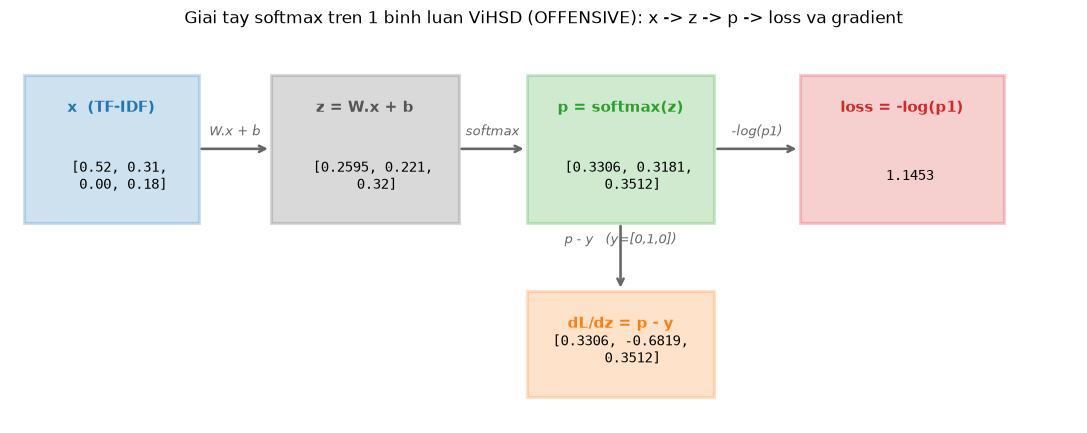

In [5]:
# === So do giai tay (anh nhung trong notebook de xem) ===
fig, ax = plt.subplots(figsize=(12.5, 4.6))
ax.set_xlim(0, 12.5); ax.set_ylim(0, 4.6); ax.axis("off")

def box(x, y, w, h, title, body, color):
    ax.add_patch(plt.Rectangle((x, y), w, h, fill=True, facecolor=color,
                               alpha=0.22, edgecolor=color, lw=2))
    ax.text(x + w / 2, y + h - 0.30, title, ha="center", va="top",
            fontsize=10, fontweight="bold", color=color)
    ax.text(x + w / 2, y + 0.55, body, ha="center", va="center",
            fontsize=9, family="monospace")

def arrow(x1, y1, x2, y2, label):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.7, color="#666"))
    ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.16, label, ha="center",
            fontsize=8.5, color="#666", style="italic")

ytop, h = 2.35, 1.75
box(0.15, ytop, 2.05, h, "x  (TF-IDF)", "  [0.52, 0.31,\n   0.00, 0.18]", "#1f77b4")
box(3.05, ytop, 2.20, h, "z = W.x + b", "  [0.2595, 0.221,\n   0.32]", "#555555")
box(6.05, ytop, 2.20, h, "p = softmax(z)", "  [0.3306, 0.3181,\n   0.3512]", "#2ca02c")
box(9.25, ytop, 2.40, h, "loss = -log(p1)", "  1.1453", "#d62728")
arrow(2.20, ytop + h / 2, 3.05, ytop + h / 2, "W.x + b")
arrow(5.25, ytop + h / 2, 6.05, ytop + h / 2, "softmax")
arrow(8.25, ytop + h / 2, 9.25, ytop + h / 2, "-log(p1)")
# Nhanh gradient (p - y) duoi p
box(6.05, 0.30, 2.20, 1.25, "dL/dz = p - y", "[0.3306, -0.6819,\n   0.3512]", "#ff7f0e")
arrow(7.15, ytop, 7.15, 1.55, "p - y   (y=[0,1,0])")
ax.set_title("Giai tay softmax tren 1 binh luan ViHSD (OFFENSIVE): x -> z -> p -> loss va gradient",
             fontsize=11, pad=6)
plt.show()

## 4. Giai đoạn 2 — BẢN THUẦN (NumPy duy nhất, không thư viện ML)

Cài đặt trực tiếp từ công thức Mục 3, áp dụng lên ma trận TF-IDF thật (3 000 chiều):
- **Trừ max trước khi exp**: vì softmax bất biến cộng, tính $e^{z-\max z}$ cho cùng kết quả nhưng tránh tràn số.
- **One-hot nhãn**: để công thức gradient $X^{\top}(P-Y)/N$ gọn.
- **Gradient descent nguyên bản** với **học suất cố định** (`lr=1.0`), 300 vòng: cập nhật $W \leftarrow W - \eta\,\partial\mathcal{L}/\partial W$. **Không có chính quy hoá L2** — đây là điểm then chốt để giải thích khoảng cách với thư viện ở Mục 6.

BAN THUAN:  train acc = 0.7119 | test acc = 0.6200 | F1-macro = 0.6185 | loss = 0.9424 | 3.67s


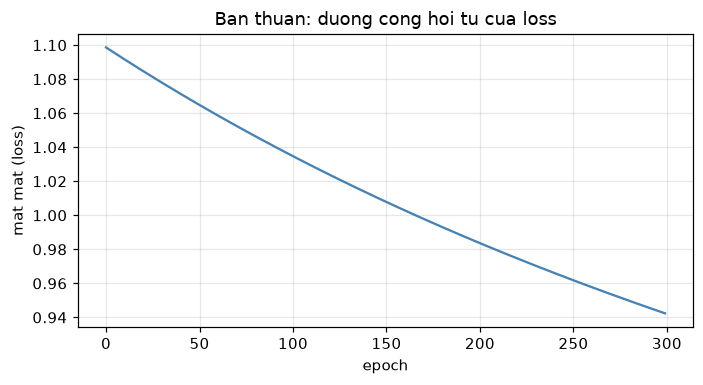

In [6]:
def train_pure(X, y, K=3, lr=1.0, epochs=300, seed=0):
    """Softmax regression bang GD nguyen ban - chi dung NumPy."""
    rng = np.random.default_rng(seed)
    W = rng.normal(size=(X.shape[1], K)) * 0.01       # khoi tao nho
    b = np.zeros(K)
    Y = np.eye(K)[y]                                  # one-hot
    hist = []
    for _ in range(epochs):
        L, gW, gb = loss_and_grad(W, b, X, Y)
        hist.append(L)
        W -= lr * gW
        b -= lr * gb
    return W, b, hist

def predict(W, b, X):
    return softmax(X @ W + b).argmax(axis=1)

t0 = time.perf_counter()
W_p, b_p, hist = train_pure(Xtr, ytr, K=3, lr=1.0, epochs=300)
t_pure = time.perf_counter() - t0
acc_tr_p = (predict(W_p, b_p, Xtr) == ytr).mean()
acc_te_p = (predict(W_p, b_p, Xte) == yte).mean()
f1_te_p  = f1_score(yte, predict(W_p, b_p, Xte), average="macro")
print("BAN THUAN:  train acc = %.4f | test acc = %.4f | F1-macro = %.4f | loss = %.4f | %.2fs"
      % (acc_tr_p, acc_te_p, f1_te_p, hist[-1], t_pure))

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(hist, color="steelblue"); ax.set_xlabel("epoch"); ax.set_ylabel("mat mat (loss)")
ax.set_title("Ban thuan: duong cong hoi tu cua loss"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 5. Giai đoạn 3 — BẢN THƯ VIỆN (scikit-learn)

`LogisticRegression` của scikit-learn (mặc định solver **LBFGS**, mô hình **multinomial** = đúng softmax) hội tụ sâu hơn GD nguyên bản trên bài toán lồi: LBFGS là giải thuật bậc hai (xấp xỉ Hessian), đồng thời sklearn **mặc định bật chính quy hoá L2** (`C=1`). Hai yếu tố này — solver mạnh hơn và có L2 — chính là lý do bản thư viện vượt bản thuần (so sánh ở Mục 6).

In [7]:
from sklearn.linear_model import LogisticRegression

t0 = time.perf_counter()
clf = LogisticRegression(max_iter=300).fit(Xtr, ytr)
t_lib = time.perf_counter() - t0
acc_tr_l = clf.score(Xtr, ytr)
acc_te_l = clf.score(Xte, yte)
f1_te_l  = f1_score(yte, clf.predict(Xte), average="macro")
print("BAN LIB (sklearn, LBFGS + L2):  train acc = %.4f | test acc = %.4f | F1-macro = %.4f | %.3fs"
      % (acc_tr_l, acc_te_l, f1_te_l, t_lib))

print("\nBao cao phan loai chi tiet (tap test):")
print(classification_report(yte, clf.predict(Xte),
                            target_names=[cls[i] for i in range(3)], digits=4))

BAN LIB (sklearn, LBFGS + L2):  train acc = 0.8308 | test acc = 0.6450 | F1-macro = 0.6439 | 6.006s

Bao cao phan loai chi tiet (tap test):
              precision    recall  f1-score   support

       CLEAN     0.6882    0.7175    0.7026       400
   OFFENSIVE     0.6141    0.5650    0.5885       400
        HATE     0.6289    0.6525    0.6405       400

    accuracy                         0.6450      1200
   macro avg     0.6438    0.6450    0.6439      1200
weighted avg     0.6438    0.6450    0.6439      1200



## 6. So sánh bản thuần và bản thư viện

Cùng dữ liệu, cùng phân chia, cùng TF-IDF. Vì dữ liệu lệch, **F1-macro là thước đo chính** (accuracy bị lớp CLEAN áp đảo).

Phuong an                       | train     | test      | F1-macro  | giay  
------------------------------------------------------------------------
Ban thuan (NumPy, GD, lr=1.0)   | 0.7119    | 0.6200    | 0.6185    | 3.67  
Ban lib (sklearn, LBFGS + L2)   | 0.8308    | 0.6450    | 0.6439    | 6.01  


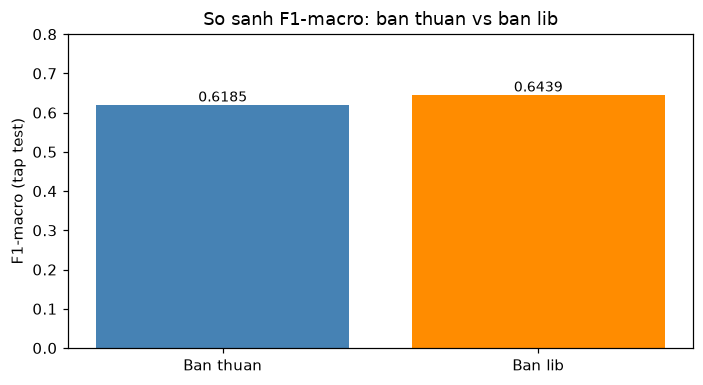


Nhan xet: ban thuần YEU HON ban lib (F1-macro 0.6185 < 0.6439).
Ly do trung thuc: ban thuan dung GD co hoc suat co dinh, KHONG co L2;
sklearn dung LBFGS (bac 2) + mac dinh bat L2 -> hoi tu sau hon, ket qua tot hon.


In [8]:
rows = [
    ("Ban thuan (NumPy, GD, lr=1.0)", "%.4f" % acc_tr_p, "%.4f" % acc_te_p, "%.4f" % f1_te_p, "%.2f" % t_pure),
    ("Ban lib (sklearn, LBFGS + L2)", "%.4f" % acc_tr_l, "%.4f" % acc_te_l, "%.4f" % f1_te_l, "%.2f" % t_lib),
]
print("%-31s | %-9s | %-9s | %-9s | %-6s" % ("Phuong an", "train", "test", "F1-macro", "giay"))
print("-" * 72)
for r in rows:
    print("%-31s | %-9s | %-9s | %-9s | %-6s" % r)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
names = ["Ban thuan", "Ban lib"]
vals = [f1_te_p, f1_te_l]
ax.bar(names, vals, color=["steelblue", "darkorange"])
ax.set_ylabel("F1-macro (tap test)"); ax.set_ylim(0, 0.8)
ax.set_title("So sanh F1-macro: ban thuan vs ban lib")
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, "%.4f" % v, ha="center", fontsize=9)
fig.tight_layout(); plt.show()

print("\nNhan xet: ban thuần YEU HON ban lib (F1-macro %.4f < %.4f)." % (f1_te_p, f1_te_l))
print("Ly do trung thuc: ban thuan dung GD co hoc suat co dinh, KHONG co L2;")
print("sklearn dung LBFGS (bac 2) + mac dinh bat L2 -> hoi tu sau hon, ket qua tot hon.")

## 7. Kết luận

- **Bản thuần** mô hình hoá đúng softmax regression (gradient $\partial\mathcal{L}/\partial W = X^{\top}(P-Y)/N$ đã kiểm chứng bằng sai phân hữu hạn), nhưng **yếu hơn** thư viện vì: (i) dùng gradient descent với **học suất cố định**, (ii) **không có chính quy hoá L2**, (iii) hội tụ chưa sâu sau 300 vòng. Khoảng cách F1-macro (~0.62 vs ~0.64) chính là **điểm dạy học**: hiểu nguyên lý bằng bản thuần, triển khai thực tế bằng thư viện.
- **F1-macro** là thước đo đúng cho bài toán này vì ViHSD rất lệch (CLEAN áp đảo) — accuracy sẽ đánh lừa, giống phân tích EDA ở `b1`/`b3`.
- **Phần chuẩn bị dữ liệu TF-IDF là chung** cho cả hai bản: văn bản → vector số; chỉ phần tối ưu trọng số khác nhau.
- **Khi nào dùng cái nào?** Muốn **hiểu** mô hình hoạt động thế nào → bản thuần; muốn **triển khai** nhanh, ổn định, chính xác → thư viện.

> Cùng một mô hình softmax, cùng một phương pháp 4 giai đoạn — Iris (đặc trưng số đo hoa) và ViHSD (đặc trưng TF-IDF) chỉ khác nhau ở cách tạo $x$.